# Bird vs. Forest Classifier

Fine-tunes a pretrained ResNet18 to tell photos of **birds** apart from photos of **forests**.

Pipeline: download images -> clean corrupt files -> split train/val -> two-stage
fine-tuning (frozen backbone, then full unfreeze) -> save/load model -> run
predictions on new images (local file or URL).

Works both locally and in Google Colab. Set `USE_COLAB_DRIVE = True` below if you
want the model saved to/loaded from Google Drive; otherwise everything is saved
next to the notebook.


In [2]:
import os
import shutil
from pathlib import Path
from io import BytesIO

import numpy as np
import requests
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt

# ---- Configuration ----------------------------------------------------
DATA_DIR = Path("bird_or_not")          # where images are stored
MODEL_PATH = Path("resnet18_bird_or_forest.pth")
CLASSES = ["bird", "forest"]
IMAGES_PER_CLASS = 60                    # more than the original 27/30 for a sturdier model
IMG_SIZE = 192
BATCH_SIZE = 16
FREEZE_EPOCHS = 3                        # stage 1: train only the new head
UNFREEZE_EPOCHS = 8                      # stage 2: fine-tune the whole network
VAL_FRACTION = 0.2
SEED = 42

USE_COLAB_DRIVE = False   # set True to persist the model to Google Drive in Colab
DRIVE_MODEL_PATH = "/content/drive/MyDrive/bird_or_not/resnet18_bird_or_forest.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Matplotlib is building the font cache; this may take a moment.


Using device: cuda


## 1. Download the dataset

Install once if needed: `pip install ddgs`


In [12]:
from ddgs import DDGS
import time


FRESH_DOWNLOAD = True  # wipe DATA_DIR first so old/partial runs can't hide a failed download

if FRESH_DOWNLOAD and DATA_DIR.exists():
    shutil.rmtree(DATA_DIR)
DATA_DIR.mkdir(parents=True, exist_ok=True)

HEADERS = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Safari/537.36"}

QUERIES = {
    "bird": ["bird photo", "bird close up", "wild bird flying", "sparrow bird", "bird perched on branch"],
    "forest": ["forest landscape", "forest trees path", "woodland forest", "pine forest"],
}


def try_download(url, dest_path, timeout=8):
    """Download url, verify it's a real image, save it. Returns True on success."""
    try:
        r = requests.get(url, headers=HEADERS, timeout=timeout)
        r.raise_for_status()
        Image.open(BytesIO(r.content)).verify()  # raises if not a valid image
        with open(dest_path, "wb") as f:
            f.write(r.content)
        return True
    except Exception:
        return False


for cls, queries in QUERIES.items():
    dest = DATA_DIR / cls
    dest.mkdir(parents=True, exist_ok=True)
    per_query_target = max(10, IMAGES_PER_CLASS // len(queries))
    class_total = 0

    for query in queries:
        with DDGS() as ddgs:
            # ask for extra results since some URLs will fail to download
            results = list(ddgs.images(query=query, max_results=per_query_target * 3))

        saved_this_query = 0
        for i, r in enumerate(results):
            url = r.get("image")
            if not url:
                continue
            dest_path = dest / f"{query.replace(' ', '_')}_{i:03d}.jpg"
            if try_download(url, dest_path):
                saved_this_query += 1
                if saved_this_query >= per_query_target:
                    break

        print(f"  '{query}': {saved_this_query} images saved")
        class_total += saved_this_query
        time.sleep(1)  # be polite between queries

    print(f"{cls}: {class_total} total images saved\n")

2026-09-27 08:57:17,104 - INFO - ddgs.ddgs - Error in engine duckduckgo: DDGSException("RequestError: RequestError('error sending request for url (https://duckduckgo.com/?q=bird+photo) > user error: malformed headers')")
2026-09-27 08:57:17,622 - INFO - primp - response: https://www.bing.com/images/async?q=bird+photo&async=1&first=1&count=35 200


  'bird photo': 12 images saved


2026-09-27 08:59:00,047 - INFO - ddgs.ddgs - Error in engine duckduckgo: DDGSException("RequestError: RequestError('error sending request for url (https://duckduckgo.com/?q=bird+close+up) > user error: malformed headers')")
2026-09-27 08:59:00,980 - INFO - primp - response: https://www.bing.com/images/async?q=bird+close+up&async=1&first=1&count=35 200


  'bird close up': 12 images saved


2026-09-27 09:00:25,890 - INFO - primp - response: https://www.bing.com/images/async?q=wild+bird+flying&async=1&first=1&count=35 200


...

  'forest trees path': 15 images saved


2026-09-27 09:15:31,674 - INFO - primp - response: https://www.bing.com/images/async?q=woodland+forest&async=1&first=1&count=35 200


  'woodland forest': 15 images saved


2026-09-27 09:20:04,433 - INFO - primp - response: https://www.bing.com/images/async?q=pine+forest&async=1&first=1&count=35 200


  'pine forest': 15 images saved
forest: 60 total images saved



In [13]:
# Remove any file that isn't a valid, openable image (corrupt / truncated downloads)
removed = 0
for img_path in DATA_DIR.rglob("*"):
    if img_path.is_file() and img_path.suffix.lower() in (".jpg", ".jpeg", ".png", ".webp"):
        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception:
            img_path.unlink(missing_ok=True)
            removed += 1            

print(f"Removed {removed} corrupt files")
for cls in CLASSES:
    print(f"{cls}: {len(list((DATA_DIR / cls).iterdir()))} usable images")


Removed 0 corrupt files
bird: 60 usable images
forest: 60 usable images


## 2. Build datasets and dataloaders

In [14]:
data_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

full_dataset = datasets.ImageFolder(root=str(DATA_DIR), transform=data_transforms)
class_names = full_dataset.classes
print("Classes found:", class_names)

val_size = max(1, int(len(full_dataset) * VAL_FRACTION))
train_size = len(full_dataset) - val_size
generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} images | Val: {len(val_dataset)} images")


Classes found: ['bird', 'forest']
Train: 96 images | Val: 24 images


## 3. Model + two-stage fine-tuning

**Stage 1** — freeze the pretrained backbone and train only the new final
layer, so the randomly-initialized head doesn't wreck the pretrained weights
with big early gradients.

**Stage 2** — unfreeze everything and fine-tune the whole network at a lower
learning rate.


In [15]:
def build_model(num_classes=2):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    torch.set_grad_enabled(is_train)
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        if is_train:
            optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += inputs.size(0)

    return total_loss / total, correct / total


model = build_model(num_classes=len(class_names))
criterion = nn.CrossEntropyLoss()


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\abdou/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [04:43<00:00, 165kB/s] 


In [16]:
# ---- Stage 1: train the new head only ----
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
print(f"--- Stage 1: fine-tuning head only ({FREEZE_EPOCHS} epochs) ---")
for epoch in range(1, FREEZE_EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion)
    print(f"Epoch {epoch} | Train Loss: {train_loss:.4f}, Acc: {train_acc:.2%} "
          f"| Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2%}")


--- Stage 1: fine-tuning head only (3 epochs) ---
Epoch 1 | Train Loss: 0.6021, Acc: 60.42% | Val Loss: 0.3650, Val Acc: 83.33%
Epoch 2 | Train Loss: 0.3393, Acc: 91.67% | Val Loss: 0.1937, Val Acc: 100.00%
Epoch 3 | Train Loss: 0.2446, Acc: 95.83% | Val Loss: 0.1193, Val Acc: 100.00%


In [17]:
# ---- Stage 2: unfreeze everything, fine-tune with a smaller learning rate ----
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=1e-4)
print(f"--- Stage 2: full fine-tuning ({UNFREEZE_EPOCHS} epochs) ---")
for epoch in range(1, UNFREEZE_EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion)
    print(f"Epoch {epoch} | Train Loss: {train_loss:.4f}, Acc: {train_acc:.2%} "
          f"| Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2%}")


--- Stage 2: full fine-tuning (8 epochs) ---
Epoch 1 | Train Loss: 0.0611, Acc: 100.00% | Val Loss: 0.0032, Val Acc: 100.00%
Epoch 2 | Train Loss: 0.0245, Acc: 100.00% | Val Loss: 0.0004, Val Acc: 100.00%
Epoch 3 | Train Loss: 0.0049, Acc: 100.00% | Val Loss: 0.0015, Val Acc: 100.00%
Epoch 4 | Train Loss: 0.0019, Acc: 100.00% | Val Loss: 0.0019, Val Acc: 100.00%
Epoch 5 | Train Loss: 0.0006, Acc: 100.00% | Val Loss: 0.0017, Val Acc: 100.00%
Epoch 6 | Train Loss: 0.0057, Acc: 100.00% | Val Loss: 0.0008, Val Acc: 100.00%
Epoch 7 | Train Loss: 0.0004, Acc: 100.00% | Val Loss: 0.0006, Val Acc: 100.00%
Epoch 8 | Train Loss: 0.0024, Acc: 100.00% | Val Loss: 0.0004, Val Acc: 100.00%


## 4. Save and (re)load the model

In [18]:
torch.save(model.state_dict(), MODEL_PATH)
print(f"Saved model to {MODEL_PATH.resolve()}")

if USE_COLAB_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    Path(DRIVE_MODEL_PATH).parent.mkdir(parents=True, exist_ok=True)
    shutil.copy(MODEL_PATH, DRIVE_MODEL_PATH)
    print(f"Also copied to {DRIVE_MODEL_PATH}")


Saved model to C:\Users\abdou\Downloads\resnet18_bird_or_forest.pth


In [21]:
# Reload from scratch, exactly as you would in a new session
loaded_model = build_model(num_classes=len(class_names))
load_from = DRIVE_MODEL_PATH if USE_COLAB_DRIVE else MODEL_PATH
loaded_model.load_state_dict(torch.load(load_from, map_location=device))
loaded_model.to(device).eval()
print("Model restored and ready for predictions.")


Model restored and ready for predictions.


C:\Users\abdou\AppData\Local\Temp\ipykernel_38700\3958600513.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(load_from, map_locat

## 5. Visualize a training batch

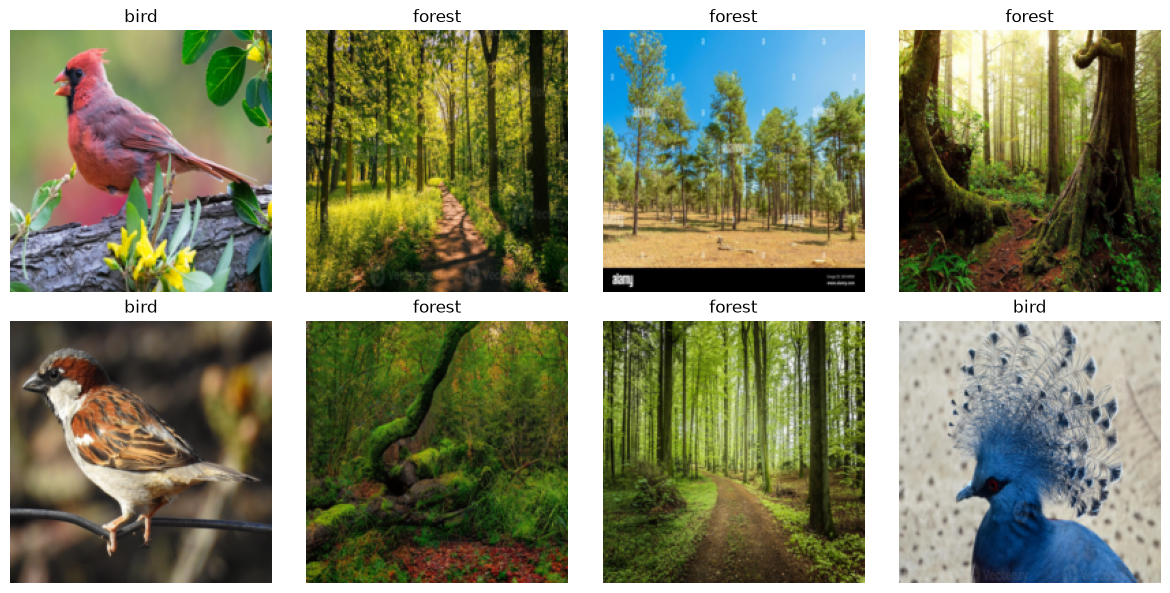

In [22]:
def imshow(tensor_img, title=None):
    img = tensor_img.cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = np.clip(std * img + mean, 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis("off")


inputs, labels = next(iter(train_loader))
plt.figure(figsize=(12, 6))
for i in range(min(8, inputs.size(0))):
    plt.subplot(2, 4, i + 1)
    imshow(inputs[i], title=class_names[labels[i]])
plt.tight_layout()
plt.show()


## 6. Run predictions on new images (local path or URL)

In [23]:
def predict_image(image_source, model, transform, class_names, device):
    """image_source: local file path OR http(s) URL"""
    if str(image_source).startswith(("http://", "https://")):
        headers = {"User-Agent": "Mozilla/5.0"}
        response = requests.get(image_source, headers=headers, timeout=10)
        response.raise_for_status()
        img = Image.open(BytesIO(response.content)).convert("RGB")
    else:
        img = Image.open(image_source).convert("RGB")

    tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = F.softmax(model(tensor), dim=1)[0]
    idx = probs.argmax().item()
    return class_names[idx], probs[idx].item()


# Example: predict on a sample image URL
sample_url = "https://images.unsplash.com/photo-1552728089-57bdde30beb3?w=500"
label, prob = predict_image(sample_url, loaded_model, data_transforms, class_names, device)
print(f"Prediction: {label} ({prob:.2%} confidence)")


Prediction: bird (99.99% confidence)
